
# RELLIS-3D Fine-tuning Qualitative Comparison

This notebook compares:

- **Exp2**: RUGD-trained checkpoint evaluated directly on RELLIS-3D
- **Exp3**: the same architecture after target-domain fine-tuning on RELLIS-3D

Final paper figure layout:

| Case | Input | Ground Truth | Cross-dataset | Fine-tuned |
|---|---|---|---|---|
| Strong recovery | DeepLabV3+ | | | |
| Non-ground recovery | U-Net | | | |
| Residual challenge | ROD | | | |

The notebook **does not retrain models**. It loads existing checkpoints and only performs inference.


In [1]:

# 1. Mount Drive and install dependencies

from google.colab import drive
drive.mount("/content/drive")

!pip -q install segmentation-models-pytorch einops opencv-python-headless pandas matplotlib tqdm

import os
import re
import sys
import json
import shutil
import zipfile
import subprocess
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.1 MB/s eta 0:00:00
Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [2]:

# 2. Configuration

DATASET_ZIP = Path(
    "/content/drive/MyDrive/IRP/01_data/processed/RELLIS_3D_binary_processed.zip"
)

EXP2_CHECKPOINTS = {
    "U-Net": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "unet_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),
    "DeepLabV3+": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),
    "SegFormer-B0": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "segformer_b0_rugd_binary_ground_best_20epochs.pth"
    ),
    "ROD": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "rod_rugd_binary_ground_best_20epochs.pth"
    ),
}

EXP3_CHECKPOINTS = {
    "U-Net": Path(
        "/content/drive/MyDrive/IRP/04_target_domain_finetuning/rellis3d/U-Net/"
        "best_rellis3d_finetuned.pth"
    ),

    "DeepLabV3+": Path(
        "/content/drive/MyDrive/IRP/04_target_domain_finetuning/rellis3d/DeepLabV3plus/"
        "best_rellis3d_finetuned.pth"
    ),

    "SegFormer-B0": Path(
        "/content/drive/MyDrive/IRP/04_target_domain_finetuning/rellis3d/SegFormer-B0/"
        "best_rellis3d_finetuned.pth"
    ),

    "ROD": Path(
        "/content/drive/MyDrive/IRP/04_target_domain_finetuning/rellis3d/ROD/"
        "best_rellis3d_finetuned.pth"
    ),
}

RESULTS_ROOT = Path(
    "/content/drive/MyDrive/IRP/04_target_domain_finetuning/rellis3d"
)

WORK_ROOT = Path("/content/rellis3d_finetune_qualitative")
EXTRACT_ROOT = WORK_ROOT / "processed"
OUTPUT_ROOT = RESULTS_ROOT / "qualitative_comparison"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

NON_GROUND_CLASS = 0
GROUND_CLASS = 1
IGNORE_INDEX = 255
NUM_CLASSES = 2
INPUT_SIZE = (512, 512)

MODEL_DISPLAY_ORDER = [
    "U-Net",
    "DeepLabV3+",
    "SegFormer-B0",
    "ROD",
]

for name, p in EXP2_CHECKPOINTS.items():
    if not p.exists():
        raise FileNotFoundError(f"Exp2 checkpoint not found for {name}: {p}")

if not DATASET_ZIP.exists():
    raise FileNotFoundError(DATASET_ZIP)

print("Configuration OK.")


Configuration OK.


In [3]:

# 4. Extract processed RELLIS-3D and build the same test dataframe

def find_file_recursively(root, filename):
    matches = list(Path(root).rglob(filename))
    return matches[0] if matches else None

EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

manifest_path = find_file_recursively(EXTRACT_ROOT, "manifest.csv")

if manifest_path is None:
    print("Extracting:", DATASET_ZIP)
    with zipfile.ZipFile(DATASET_ZIP, "r") as zf:
        zf.extractall(EXTRACT_ROOT)
    manifest_path = find_file_recursively(EXTRACT_ROOT, "manifest.csv")

if manifest_path is None:
    raise FileNotFoundError("manifest.csv not found after extraction")

DATA_ROOT = manifest_path.parent
manifest_df = pd.read_csv(manifest_path)

def resolve_column(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f"Cannot resolve column from {candidates}; available={df.columns.tolist()}"
        )
    return None

split_col = resolve_column(manifest_df, ["split", "subset", "partition"])
image_col = resolve_column(
    manifest_df,
    ["processed_image", "image_path", "image", "image_file"]
)
mask_col = resolve_column(
    manifest_df,
    ["processed_mask", "mask_path", "mask", "label_path"]
)

def resolve_path(v):
    p = Path(str(v))
    return str(p if p.is_absolute() else DATA_ROOT / p)

work_df = manifest_df.copy()
work_df["split"] = (
    work_df[split_col].astype(str).str.strip().str.lower()
    .replace({"validation": "val"})
)
work_df["image_path"] = work_df[image_col].map(resolve_path)
work_df["mask_path"] = work_df[mask_col].map(resolve_path)

test_df = work_df[work_df["split"] == "test"].reset_index(drop=True)

missing = test_df[
    ~test_df["image_path"].map(os.path.exists)
    | ~test_df["mask_path"].map(os.path.exists)
]
if len(missing):
    display(missing[["image_path", "mask_path"]].head())
    raise FileNotFoundError(f"{len(missing)} test rows contain missing files")

print("DATA_ROOT:", DATA_ROOT)
print("Test images:", len(test_df))
display(test_df[["image_path", "mask_path"]].head())


Extracting: /content/drive/MyDrive/IRP/01_data/processed/RELLIS_3D_binary_processed.zip
DATA_ROOT: /content/rellis3d_finetune_qualitative/processed/RELLIS_3D_binary_processed
Test images: 899


,image_path,mask_path
0,/content/rellis3d_finetune_qualitative/process...,/content/rellis3d_finetune_qualitative/process...
1,/content/rellis3d_finetune_qualitative/process...,/content/rellis3d_finetune_qualitative/process...
2,/content/rellis3d_finetune_qualitative/process...,/content/rellis3d_finetune_qualitative/process...
3,/content/rellis3d_finetune_qualitative/process...,/content/rellis3d_finetune_qualitative/process...
4,/content/rellis3d_finetune_qualitative/process...,/content/rellis3d_finetune_qualitative/process...


In [4]:

# 5. Preprocessing and dataset
#
# Baselines: direct 512x512 resize + ImageNet normalization
# ROD: aspect-ratio preserving pad to 512x512 + ROD/ImageNet-255 normalization

IMAGENET_MEAN_01 = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD_01  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

PIXEL_MEAN_255 = np.array([123.675, 116.28, 103.53], dtype=np.float32)
PIXEL_STD_255  = np.array([58.395, 57.12, 57.375], dtype=np.float32)


def load_mask(path):
    mask = np.array(Image.open(path))
    if mask.ndim == 3:
        if (
            np.array_equal(mask[..., 0], mask[..., 1])
            and np.array_equal(mask[..., 0], mask[..., 2])
        ):
            mask = mask[..., 0]
        else:
            raise ValueError(f"Expected grayscale binary mask: {path}")
    mask = mask.astype(np.uint8)
    values = set(np.unique(mask).tolist())
    if not values.issubset({0, 1, 255}):
        raise ValueError(f"Unexpected mask values {sorted(values)} in {path}")
    return mask


def resize_pad(image, mask, size=512):
    h, w = image.shape[:2]
    scale = size / max(h, w)
    nh = int(round(h * scale))
    nw = int(round(w * scale))

    image_r = cv2.resize(image, (nw, nh), interpolation=cv2.INTER_LINEAR)
    mask_r = cv2.resize(mask, (nw, nh), interpolation=cv2.INTER_NEAREST)

    top = (size - nh) // 2
    bottom = size - nh - top
    left = (size - nw) // 2
    right = size - nw - left

    image_p = cv2.copyMakeBorder(
        image_r, top, bottom, left, right,
        cv2.BORDER_CONSTANT, value=(0, 0, 0)
    )
    mask_p = cv2.copyMakeBorder(
        mask_r, top, bottom, left, right,
        cv2.BORDER_CONSTANT, value=IGNORE_INDEX
    )

    return image_p, mask_p


class RellisInferenceDataset(Dataset):
    def __init__(self, dataframe, preprocess_mode):
        self.df = dataframe.reset_index(drop=True)
        self.preprocess_mode = preprocess_mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = np.array(Image.open(row["image_path"]).convert("RGB"))
        mask = load_mask(row["mask_path"])

        if self.preprocess_mode == "direct_resize":
            image_p = cv2.resize(
                image, INPUT_SIZE[::-1], interpolation=cv2.INTER_LINEAR
            )
            mask_p = cv2.resize(
                mask, INPUT_SIZE[::-1], interpolation=cv2.INTER_NEAREST
            )

            x = image_p.astype(np.float32) / 255.0
            x = (x - IMAGENET_MEAN_01) / IMAGENET_STD_01

        elif self.preprocess_mode == "aspect_ratio_pad":
            image_p, mask_p = resize_pad(image, mask, size=INPUT_SIZE[0])

            # This matches the ROD preprocessing used in the original RELLIS code.
            x = (image_p.astype(np.float32) - PIXEL_MEAN_255) / PIXEL_STD_255

        else:
            raise ValueError(self.preprocess_mode)

        x = torch.from_numpy(x).permute(2, 0, 1).contiguous()

        return {
            "image": x,
            "mask": torch.from_numpy(mask_p.astype(np.int64)),
            "index": torch.tensor(idx, dtype=torch.long),
        }


baseline_loader = DataLoader(
    RellisInferenceDataset(test_df, "direct_resize"),
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=(DEVICE.type == "cuda"),
)

rod_loader = DataLoader(
    RellisInferenceDataset(test_df, "aspect_ratio_pad"),
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=(DEVICE.type == "cuda"),
)

print("Baseline batches:", len(baseline_loader))
print("ROD batches:", len(rod_loader))


Baseline batches: 113
ROD batches: 899


In [5]:

# 6. Baseline model definitions
#
# IMPORTANT:
# The SegFormer checkpoint uses SMP/timm-style keys such as encoder.patch_embed1...,
# therefore use segmentation_models_pytorch.Segformer, NOT HuggingFace
# SegformerForSemanticSegmentation.

def build_baseline_model(model_name):
    if model_name == "U-Net":
        model = smp.Unet(
            encoder_name="resnet34",
            encoder_weights=None,
            in_channels=3,
            classes=NUM_CLASSES,
        )

    elif model_name == "DeepLabV3+":
        model = smp.DeepLabV3Plus(
            encoder_name="resnet34",
            encoder_weights=None,
            encoder_output_stride=16,
            in_channels=3,
            classes=NUM_CLASSES,
        )

    elif model_name == "SegFormer-B0":
        model = smp.Segformer(
            encoder_name="mit_b0",
            encoder_weights=None,
            in_channels=3,
            classes=NUM_CLASSES,
        )

    else:
        raise ValueError(model_name)

    return model.to(DEVICE)


def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for key in [
            "model_state_dict",
            "state_dict",
            "model",
            "net",
        ]:
            if key in checkpoint and isinstance(checkpoint[key], dict):
                return checkpoint[key]
    return checkpoint


def normalize_state_dict_keys(state_dict):
    # Handle DataParallel / wrapper prefixes without silently accepting architecture mismatch.
    prefixes = ["module.", "model."]

    out = dict(state_dict)

    for prefix in prefixes:
        if out and all(k.startswith(prefix) for k in out.keys()):
            out = {k[len(prefix):]: v for k, v in out.items()}

    return out


def load_checkpoint_strict(model, checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    state = normalize_state_dict_keys(extract_state_dict(checkpoint))

    try:
        model.load_state_dict(state, strict=True)
    except RuntimeError as e:
        print("\nSTRICT LOAD FAILED:", checkpoint_path)
        print("First checkpoint keys:", list(state.keys())[:10])
        print("First model keys:", list(model.state_dict().keys())[:10])
        raise RuntimeError(
            "Checkpoint/model architecture mismatch. "
            "Do not use strict=False for the final experiment."
        ) from e

    model.eval()
    return model


# Quick smoke test: load all 3 baseline Exp2 checkpoints.
for name in ["U-Net", "DeepLabV3+", "SegFormer-B0"]:
    print("Loading smoke test:", name)
    m = build_baseline_model(name)
    m = load_checkpoint_strict(m, EXP2_CHECKPOINTS[name])
    del m
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print("Baseline architecture/checkpoint smoke test passed.")


Loading smoke test: U-Net
Loading smoke test: DeepLabV3+
Loading smoke test: SegFormer-B0
Baseline architecture/checkpoint smoke test passed.


In [6]:

# 7. ROD setup and model definition

ROD_REPO = Path("/content/offroad_roadseg")

def run_command(command):
    print(command)
    subprocess.run(command, shell=True, check=True)

if not ROD_REPO.exists():
    run_command(
        "git clone --depth 1 "
        "https://github.com/ict-ans-617/offroad_roadseg.git "
        f"{ROD_REPO}"
    )

sys.path.insert(0, str(ROD_REPO))

WEIGHTS_DIR = ROD_REPO / "efficient_sam" / "weights"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

VITS_PATH = WEIGHTS_DIR / "efficient_sam_vits.pt"
VITS_ZIP_PATH = WEIGHTS_DIR / "efficient_sam_vits.pt.zip"

if not VITS_PATH.exists():
    if not VITS_ZIP_PATH.exists():
        run_command(
            "wget -q --show-progress "
            "https://github.com/yformer/EfficientSAM/raw/main/"
            "weights/efficient_sam_vits.pt.zip "
            f"-O {VITS_ZIP_PATH}"
        )
    with zipfile.ZipFile(VITS_ZIP_PATH, "r") as archive:
        archive.extractall(WEIGHTS_DIR)

from efficient_sam.build_efficient_sam import build_efficient_sam_vits
from seg_decoder import SegHead


def load_rod_encoder(checkpoint_path):
    checkpoint_path = Path(checkpoint_path).resolve()

    efficient_sam_dir = ROD_REPO / "efficient_sam"
    expected_checkpoint = (
        efficient_sam_dir / "weights" / "efficient_sam_vits.pt"
    ).resolve()

    if checkpoint_path != expected_checkpoint:
        expected_checkpoint.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(checkpoint_path, expected_checkpoint)

    cwd = Path.cwd()
    try:
        os.chdir(efficient_sam_dir)
        efficient_sam_model = build_efficient_sam_vits()
    finally:
        os.chdir(cwd)

    return efficient_sam_model.image_encoder


class ROD(nn.Module):
    def __init__(self, encoder_checkpoint, freeze=True):
        super().__init__()

        self.encoder = load_rod_encoder(encoder_checkpoint)
        self.decoder = SegHead()
        self.freeze = freeze
        self.encoder_input_size = int(self.encoder.img_size)

        if freeze:
            for p in self.encoder.parameters():
                p.requires_grad = False
            self.encoder.eval()

    def train(self, mode=True):
        super().train(mode)
        if self.freeze:
            self.encoder.eval()
        return self

    def forward(self, image):
        output_size = image.shape[-2:]

        if image.shape[-2:] != (
            self.encoder_input_size,
            self.encoder_input_size,
        ):
            encoder_input = F.interpolate(
                image,
                size=(self.encoder_input_size, self.encoder_input_size),
                mode="bilinear",
                align_corners=False,
            )
        else:
            encoder_input = image

        if self.freeze:
            with torch.no_grad():
                features = self.encoder(encoder_input)
        else:
            features = self.encoder(encoder_input)

        logits = self.decoder(features)

        if logits.shape[-2:] != output_size:
            logits = F.interpolate(
                logits,
                size=output_size,
                mode="bilinear",
                align_corners=False,
            )

        return logits


def build_rod_model():
    return ROD(VITS_PATH, freeze=True).to(DEVICE)


print("ROD Exp2 smoke test")
m = build_rod_model()
m = load_checkpoint_strict(m, EXP2_CHECKPOINTS["ROD"])
del m
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print("ROD checkpoint smoke test passed.")


git clone --depth 1 https://github.com/ict-ans-617/offroad_roadseg.git /content/offroad_roadseg
wget -q --show-progress https://github.com/yformer/EfficientSAM/raw/main/weights/efficient_sam_vits.pt.zip -O /content/offroad_roadseg/efficient_sam/weights/efficient_sam_vits.pt.zip
ROD Exp2 smoke test
ROD checkpoint smoke test passed.


In [7]:

# 8. Metric functions

def per_image_metrics(pred, target):
    pred = np.asarray(pred)
    target = np.asarray(target)

    valid = target != IGNORE_INDEX

    ious = []
    for cls in [NON_GROUND_CLASS, GROUND_CLASS]:
        p = (pred == cls) & valid
        t = (target == cls) & valid

        inter = np.logical_and(p, t).sum()
        union = np.logical_or(p, t).sum()

        ious.append(inter / union if union > 0 else np.nan)

    return {
        "non_ground_iou": ious[0],
        "ground_iou": ious[1],
        "miou": float(np.nanmean(ious)),
    }


@torch.inference_mode()
def evaluate_checkpoint_per_image(model_name, checkpoint_path):
    if model_name == "ROD":
        model = build_rod_model()
        loader = rod_loader
    else:
        model = build_baseline_model(model_name)
        loader = baseline_loader

    model = load_checkpoint_strict(model, checkpoint_path)

    rows = []

    for batch in tqdm(loader, desc=f"{model_name} | {checkpoint_path.name}"):
        images = batch["image"].to(DEVICE, non_blocking=True)
        targets = batch["mask"].cpu().numpy()
        indices = batch["index"].cpu().numpy()

        logits = model(images)

        if isinstance(logits, dict):
            logits = logits["out"]
        elif hasattr(logits, "logits"):
            logits = logits.logits

        if logits.shape[-2:] != images.shape[-2:]:
            logits = F.interpolate(
                logits,
                size=images.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        preds = logits.argmax(dim=1).cpu().numpy()

        for i in range(len(indices)):
            metrics = per_image_metrics(preds[i], targets[i])

            rows.append({
                "index": int(indices[i]),
                **metrics,
            })

    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return pd.DataFrame(rows).sort_values("index").reset_index(drop=True)


In [8]:

# 9. Evaluate only the 3 models needed for the final paper figure
#
# This is much faster than evaluating all four models:
# DeepLabV3+ -> strongest overall recovery
# U-Net       -> non-ground recovery
# ROD         -> residual challenge

CASE_MODELS = ["DeepLabV3+", "U-Net", "ROD"]

comparison_dfs = {}

for model_name in CASE_MODELS:
    cache_path = OUTPUT_ROOT / (
        model_name.lower()
        .replace("+", "plus")
        .replace("-", "_")
        + "_exp2_exp3_per_image.csv"
    )

    if cache_path.exists():
        print("Loading cached comparison:", cache_path)
        comparison_dfs[model_name] = pd.read_csv(cache_path)
        continue

    exp2_df = evaluate_checkpoint_per_image(
        model_name,
        EXP2_CHECKPOINTS[model_name],
    ).rename(columns={
        "non_ground_iou": "exp2_non_ground_iou",
        "ground_iou": "exp2_ground_iou",
        "miou": "exp2_miou",
    })

    exp3_df = evaluate_checkpoint_per_image(
        model_name,
        EXP3_CHECKPOINTS[model_name],
    ).rename(columns={
        "non_ground_iou": "exp3_non_ground_iou",
        "ground_iou": "exp3_ground_iou",
        "miou": "exp3_miou",
    })

    df = exp2_df.merge(exp3_df, on="index", how="inner")

    df["delta_miou"] = df["exp3_miou"] - df["exp2_miou"]
    df["delta_non_ground_iou"] = (
        df["exp3_non_ground_iou"] - df["exp2_non_ground_iou"]
    )
    df["delta_ground_iou"] = (
        df["exp3_ground_iou"] - df["exp2_ground_iou"]
    )

    df.to_csv(cache_path, index=False)
    comparison_dfs[model_name] = df

    print("Saved:", cache_path)

print("\nBuilt comparison DataFrames:")
for name, df in comparison_dfs.items():
    print(name, len(df))


DeepLabV3+ | deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth:   0%|          | 0/113 [00:00<?, ?it…

DeepLabV3+ | best_rellis3d_finetuned.pth:   0%|          | 0/113 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/IRP/04_target_domain_finetuning/rellis3d/qualitative_comparison/deeplabv3plus_exp2_exp3_per_image.csv


U-Net | unet_resnet34_rugd_binary_ground_best_20epochs.pth:   0%|          | 0/113 [00:00<?, ?it/s]

U-Net | best_rellis3d_finetuned.pth:   0%|          | 0/113 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/IRP/04_target_domain_finetuning/rellis3d/qualitative_comparison/u_net_exp2_exp3_per_image.csv


ROD | rod_rugd_binary_ground_best_20epochs.pth:   0%|          | 0/899 [00:00<?, ?it/s]

ROD | best_rellis3d_finetuned.pth:   0%|          | 0/899 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/IRP/04_target_domain_finetuning/rellis3d/qualitative_comparison/rod_exp2_exp3_per_image.csv

Built comparison DataFrames:
DeepLabV3+ 899
U-Net 899
ROD 899


In [9]:

# 10. Select representative cases automatically

selected_cases = {}

# Strong recovery: DeepLabV3+, largest per-image mIoU gain
row = (
    comparison_dfs["DeepLabV3+"]
    .dropna(subset=["delta_miou"])
    .sort_values("delta_miou", ascending=False)
    .iloc[0]
)
selected_cases["Strong recovery"] = {
    "model": "DeepLabV3+",
    "index": int(row["index"]),
    "exp2_miou": float(row["exp2_miou"]),
    "exp3_miou": float(row["exp3_miou"]),
    "delta_miou": float(row["delta_miou"]),
}

# Non-ground recovery: U-Net, largest non-ground IoU gain.
# Require fine-tuned mIoU >= 0.75 so the selected example is visually meaningful.
cand = comparison_dfs["U-Net"].dropna(
    subset=["delta_non_ground_iou", "exp3_miou"]
)
cand = cand[cand["exp3_miou"] >= 0.75]

row = (
    cand.sort_values("delta_non_ground_iou", ascending=False)
    .iloc[0]
)
selected_cases["Non-ground recovery"] = {
    "model": "U-Net",
    "index": int(row["index"]),
    "exp2_miou": float(row["exp2_miou"]),
    "exp3_miou": float(row["exp3_miou"]),
    "delta_miou": float(row["delta_miou"]),
}

# Residual challenge: ROD, low Exp3 mIoU but avoid pathological/empty-mask images.
cand = comparison_dfs["ROD"].dropna(subset=["exp3_miou"])
cand = cand[
    (cand["exp3_miou"] >= 0.20)
    & (cand["exp3_miou"] <= 0.75)
]

if len(cand) == 0:
    cand = comparison_dfs["ROD"].dropna(subset=["exp3_miou"])

row = cand.sort_values("exp3_miou", ascending=True).iloc[0]

selected_cases["Residual challenge"] = {
    "model": "ROD",
    "index": int(row["index"]),
    "exp2_miou": float(row["exp2_miou"]),
    "exp3_miou": float(row["exp3_miou"]),
    "delta_miou": float(row["delta_miou"]),
}

print("Selected cases:")
for case, info in selected_cases.items():
    print(
        f"{case:<22} | {info['model']:<12} | idx={info['index']:4d} | "
        f"{info['exp2_miou']:.3f} -> {info['exp3_miou']:.3f} "
        f"({info['delta_miou']:+.3f})"
    )


Selected cases:
Strong recovery        | DeepLabV3+   | idx= 125 | 0.226 -> 0.912 (+0.686)
Non-ground recovery    | U-Net        | idx= 677 | 0.510 -> 0.930 (+0.420)
Residual challenge     | ROD          | idx= 689 | 0.818 -> 0.585 (-0.233)


In [12]:

# 11. Single-image prediction for final visualisation

def preprocess_single(image, mask, model_name):
    if model_name == "ROD":
        image_p, mask_p = resize_pad(image, mask, size=INPUT_SIZE[0])
        x = (image_p.astype(np.float32) - PIXEL_MEAN_255) / PIXEL_STD_255
    else:
        image_p = cv2.resize(
            image, INPUT_SIZE[::-1], interpolation=cv2.INTER_LINEAR
        )
        mask_p = cv2.resize(
            mask, INPUT_SIZE[::-1], interpolation=cv2.INTER_NEAREST
        )
        x = image_p.astype(np.float32) / 255.0
        x = (x - IMAGENET_MEAN_01) / IMAGENET_STD_01

    x = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0).float()
    return x, mask_p


@torch.inference_mode()
def predict_selected_image(model_name, checkpoint_path, index):
    row = test_df.iloc[index]

    raw_image = np.array(Image.open(row["image_path"]).convert("RGB"))
    raw_mask = load_mask(row["mask_path"])

    x, eval_mask = preprocess_single(raw_image, raw_mask, model_name)

    if model_name == "ROD":
        model = build_rod_model()
    else:
        model = build_baseline_model(model_name)

    model = load_checkpoint_strict(model, checkpoint_path)
    x = x.to(DEVICE)

    logits = model(x)

    if isinstance(logits, dict):
        logits = logits["out"]
    elif hasattr(logits, "logits"):
        logits = logits.logits

    if logits.shape[-2:] != eval_mask.shape:
        logits = F.interpolate(
            logits,
            size=eval_mask.shape,
            mode="bilinear",
            align_corners=False,
        )

    pred = logits.argmax(dim=1)[0].cpu().numpy().astype(np.uint8)
    metrics = per_image_metrics(pred, eval_mask)

    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "raw_image": raw_image,
        "eval_mask": eval_mask,
        "prediction": pred,
        **metrics,
    }


def create_error_map(prediction, target):
    pred = np.asarray(prediction)
    target = np.asarray(target)

    vis = np.zeros((*target.shape, 3), dtype=np.uint8)

    valid = target != IGNORE_INDEX

    vis[(target == NON_GROUND_CLASS) & (pred == NON_GROUND_CLASS) & valid] = [0, 0, 0]
    vis[(target == GROUND_CLASS) & (pred == GROUND_CLASS) & valid] = [255, 255, 255]
    vis[(target == NON_GROUND_CLASS) & (pred == GROUND_CLASS) & valid] = [255, 0, 0]
    vis[(target == GROUND_CLASS) & (pred == NON_GROUND_CLASS) & valid] = [0, 0, 255]
    vis[target == IGNORE_INDEX] = [140, 140, 140]

    return vis

def restore_from_padding(array, padded_mask, original_shape, is_mask=True):
    """
    Remove aspect-ratio padding using the valid region in padded_mask,
    then resize back to the original image size.

    array:
        prediction or mask in padded 512x512 coordinates

    padded_mask:
        corresponding ground-truth mask containing IGNORE_INDEX in padding

    original_shape:
        (H, W) of original RGB image
    """

    valid = padded_mask != IGNORE_INDEX

    ys, xs = np.where(valid)

    if len(xs) == 0 or len(ys) == 0:
        raise ValueError("No valid pixels found in padded mask.")

    y_min, y_max = ys.min(), ys.max() + 1
    x_min, x_max = xs.min(), xs.max() + 1

    cropped = array[
        y_min:y_max,
        x_min:x_max
    ]

    original_h, original_w = original_shape

    interpolation = (
        cv2.INTER_NEAREST
        if is_mask
        else cv2.INTER_LINEAR
    )

    restored = cv2.resize(
        cropped,
        (original_w, original_h),
        interpolation=interpolation,
    )

    return restored


def ground_truth_rgb(target):
    vis = np.zeros((*target.shape, 3), dtype=np.uint8)
    vis[target == NON_GROUND_CLASS] = [0, 0, 0]
    vis[target == GROUND_CLASS] = [255, 255, 255]
    vis[target == IGNORE_INDEX] = [140, 140, 140]
    return vis


Rendering Strong recovery: DeepLabV3+, index=125
Rendering Non-ground recovery: U-Net, index=677
Rendering Residual challenge: ROD, index=689


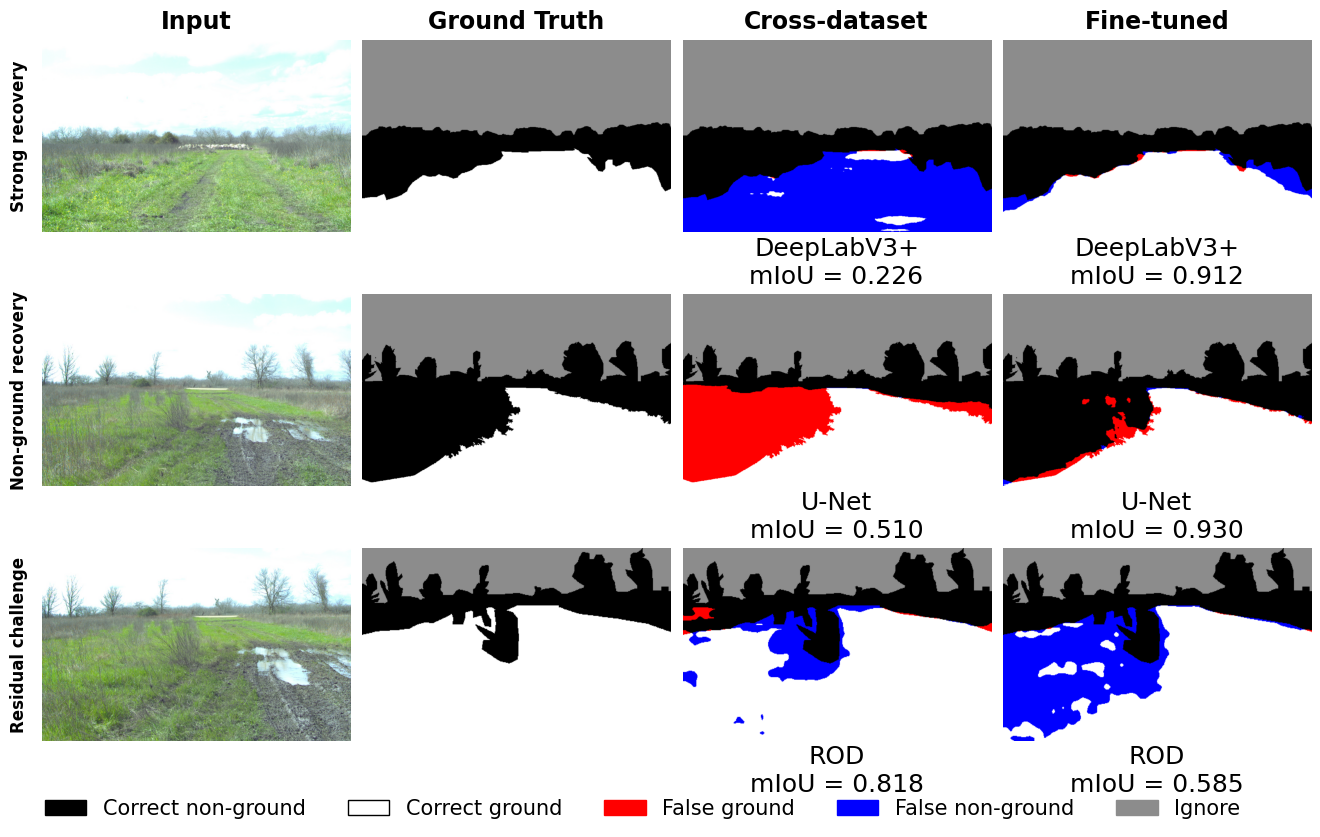

Saved figure:
/content/drive/MyDrive/IRP/04_target_domain_finetuning/rellis3d/qualitative_comparison/rugd_to_rellis3d_finetuning_qualitative.png


In [16]:
# ============================================================
# 12. Generate final paper figure
# ============================================================

figure_rows = {}

for case_name, info in selected_cases.items():

    model_name = info["model"]
    idx = info["index"]

    print(
        f"Rendering {case_name}: "
        f"{model_name}, index={idx}"
    )

    exp2 = predict_selected_image(
        model_name,
        EXP2_CHECKPOINTS[model_name],
        idx,
    )

    exp3 = predict_selected_image(
        model_name,
        EXP3_CHECKPOINTS[model_name],
        idx,
    )

    figure_rows[case_name] = {
        "model": model_name,
        "index": idx,
        "exp2": exp2,
        "exp3": exp3,
    }


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(13.5, 8.6),
)

column_titles = [
    "Input",
    "Ground Truth",
    "Cross-dataset",
    "Fine-tuned",
]


# ------------------------------------------------------------
# Column titles
# ------------------------------------------------------------

for c, title in enumerate(column_titles):

    axes[0, c].set_title(
        title,
        fontsize=17,
        fontweight="bold",
        pad=8,
    )


# ------------------------------------------------------------
# Rows
# ------------------------------------------------------------

for r, (case_name, row_info) in enumerate(
    figure_rows.items()
):

    model_name = row_info["model"]

    exp2 = row_info["exp2"]
    exp3 = row_info["exp3"]

    raw_image = exp2["raw_image"]

    original_h, original_w = (
        raw_image.shape[:2]
    )

    # ========================================================
    # Restore ROD padded results to original image dimensions
    # ========================================================

    if model_name == "ROD":

        gt_display = restore_from_padding(
            exp2["eval_mask"],
            exp2["eval_mask"],
            (original_h, original_w),
            is_mask=True,
        )

        pred2_display = restore_from_padding(
            exp2["prediction"],
            exp2["eval_mask"],
            (original_h, original_w),
            is_mask=True,
        )

        pred3_display = restore_from_padding(
            exp3["prediction"],
            exp3["eval_mask"],
            (original_h, original_w),
            is_mask=True,
        )

    else:

        # For the other models, resize masks/predictions
        # from 512x512 back to the original image dimensions.

        gt_display = cv2.resize(
            exp2["eval_mask"],
            (original_w, original_h),
            interpolation=cv2.INTER_NEAREST,
        )

        pred2_display = cv2.resize(
            exp2["prediction"],
            (original_w, original_h),
            interpolation=cv2.INTER_NEAREST,
        )

        pred3_display = cv2.resize(
            exp3["prediction"],
            (original_w, original_h),
            interpolation=cv2.INTER_NEAREST,
        )


    # --------------------------------------------------------
    # Input
    # --------------------------------------------------------

    axes[r, 0].imshow(
        raw_image
    )


    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    axes[r, 1].imshow(
        ground_truth_rgb(
            gt_display
        )
    )


    # --------------------------------------------------------
    # Cross-dataset
    # --------------------------------------------------------

    axes[r, 2].imshow(
        create_error_map(
            pred2_display,
            gt_display,
        )
    )


    # --------------------------------------------------------
    # Fine-tuned
    # --------------------------------------------------------

    axes[r, 3].imshow(
        create_error_map(
            pred3_display,
            gt_display,
        )
    )


    # --------------------------------------------------------
    # mIoU labels
    # --------------------------------------------------------

    axes[r, 2].set_xlabel(
        (
            f"{model_name}\n"
            f"mIoU = {exp2['miou']:.3f}"
        ),
        fontsize=18,
        labelpad=3,
    )

    axes[r, 3].set_xlabel(
        (
            f"{model_name}\n"
            f"mIoU = {exp3['miou']:.3f}"
        ),
        fontsize=18,
        labelpad=3,
    )


    # --------------------------------------------------------
    # Row labels
    # --------------------------------------------------------

    axes[r, 0].set_ylabel(
        case_name,
        fontsize=12,
        fontweight="bold",
        labelpad=10,
    )


    # --------------------------------------------------------
    # Remove axes
    # --------------------------------------------------------

    for c in range(4):

        axes[r, c].set_xticks([])
        axes[r, c].set_yticks([])

        for spine in (
            axes[r, c]
            .spines.values()
        ):
            spine.set_visible(False)


# ============================================================
# Legend
# ============================================================

legend_handles = [

    mpatches.Patch(
        facecolor="black",
        edgecolor="black",
        label="Correct non-ground",
    ),

    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        label="Correct ground",
    ),

    mpatches.Patch(
        facecolor="red",
        edgecolor="red",
        label="False ground",
    ),

    mpatches.Patch(
        facecolor="blue",
        edgecolor="blue",
        label="False non-ground",
    ),

    mpatches.Patch(
        facecolor="0.55",
        edgecolor="0.55",
        label="Ignore",
    ),
]


fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=15,
    bbox_to_anchor=(0.5, 0.005),
)


# ============================================================
# IMPORTANT: manually control spacing
# ============================================================

plt.subplots_adjust(
    left=0.055,
    right=0.995,
    top=0.94,
    bottom=0.11,

    # Horizontal distance between columns
    wspace=0.04,

    # Vertical distance between rows
    hspace=0.24,
)


# ============================================================
# Save
# ============================================================

FIG_PATH = (
    OUTPUT_ROOT
    / "rugd_to_rellis3d_finetuning_qualitative.png"
)

plt.savefig(
    FIG_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:")
print(FIG_PATH)


## Notes

- If automatic Exp3 checkpoint discovery selects the wrong file, manually edit `EXP3_CHECKPOINTS` in Cell 3.
- The code deliberately uses **strict checkpoint loading**. If it fails, fix the architecture/checkpoint pairing rather than using `strict=False`, because silent partial loading would invalidate the comparison.
- Per-image comparison CSV files are cached under `RESULTS_ROOT/qualitative_comparison/`; rerunning the notebook will reuse them.
